In [19]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import csv
import plotly.figure_factory as ff

In [20]:
in_checks = "../data/samples_3/test2/checks.csv"
out_checks = "../data/samples_3/test2/metrics1/perturb1/generate/ptb_results.csv"

base = pd.read_csv(in_checks, quoting=csv.QUOTE_NONNUMERIC, index_col=0)
base.index = base.index.astype(int)

perturb = pd.read_csv(out_checks, quoting=csv.QUOTE_NONNUMERIC, index_col=0)
perturb.index = perturb.index.astype(int)

In [10]:
# --- 1. Подготовка данных ---
# Замените эти списки на ваши реальные данные
# Для примера сгенерируем две группы (разного размера, но похожие по природе)
list1 = base["similarity"].tolist()
list2 = perturb["similarity"].tolist()

# --- 2. Вычисление квантилей ---
# Создаем 100 точек от 0 до 100 (процентили)
percentiles = np.linspace(0, 100, 100)

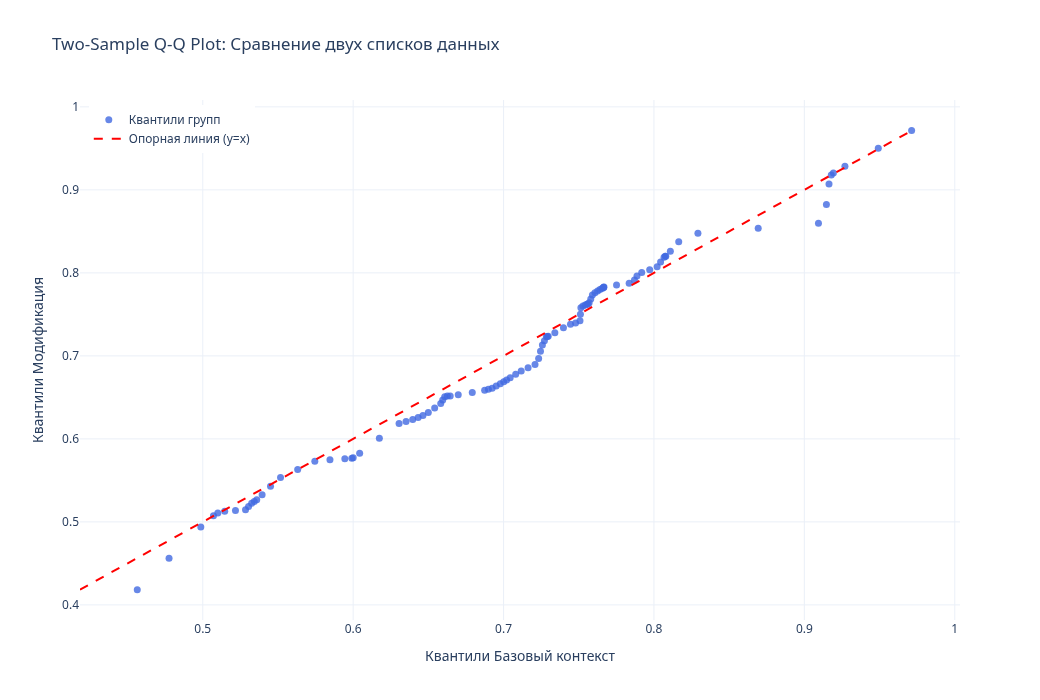

In [12]:
# Находим значения этих процентилей для каждой группы
q1 = np.percentile(list1, percentiles)
q2 = np.percentile(list2, percentiles)

# --- 3. Построение графика в Plotly ---
fig = go.Figure()

# Добавляем точки квантилей (Scatter plot)
fig.add_trace(go.Scatter(
    x=q1, 
    y=q2, 
    mode='markers',
    name='Квантили групп',
    marker=dict(color='royalblue', size=7, opacity=0.8)
))

# Добавляем опорную линию (y = x)
# Если распределения одинаковые, точки лягут ровно на эту красную пунктирную линию
min_val = min(min(q1), min(q2))
max_val = max(max(q1), max(q2))

fig.add_trace(go.Scatter(
    x=[min_val, max_val], 
    y=[min_val, max_val], 
    mode='lines',
    name='Опорная линия (y=x)',
    line=dict(color='red', dash='dash', width=2)
))

# Настраиваем внешний вид (Layout)
fig.update_layout(
    title='Two-Sample Q-Q Plot: Сравнение двух списков данных',
    xaxis_title='Квантили Базовый контекст',
    yaxis_title='Квантили Модификация',
    width=700,
    height=700,
    template='plotly_white',  # Светлая тема
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

# Показываем график
fig.show()

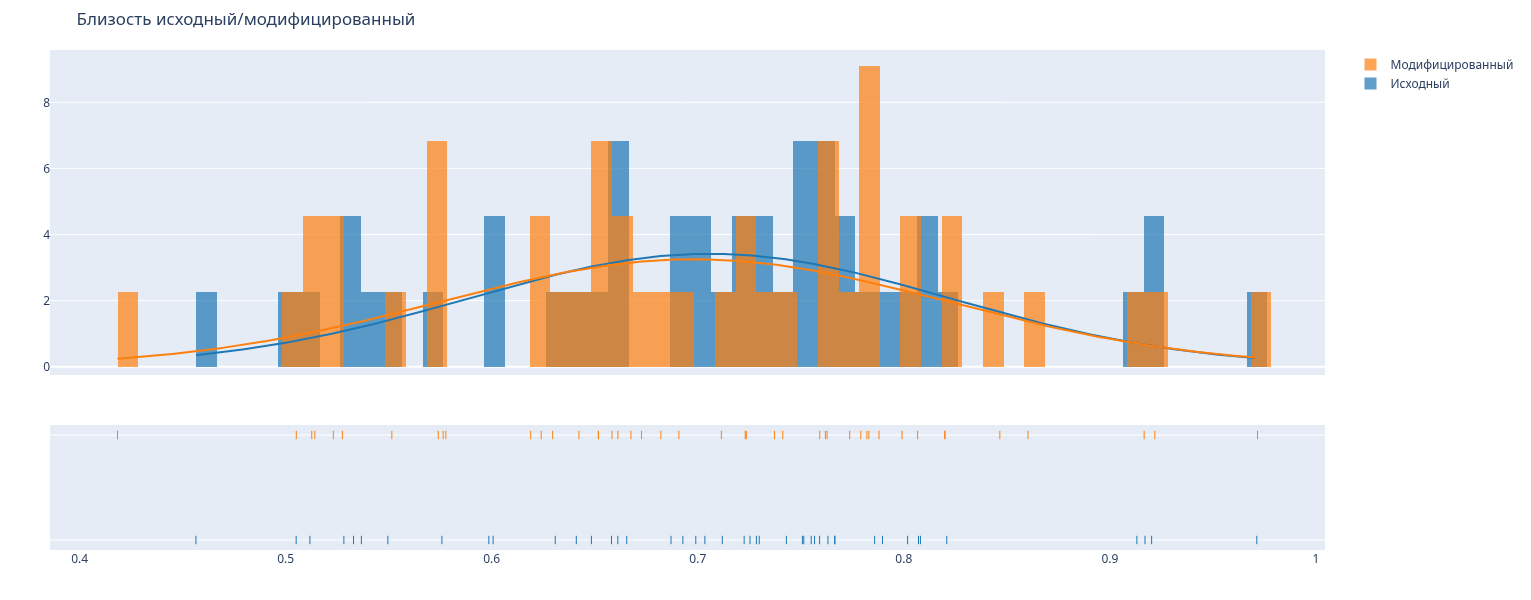

In [16]:
group_labels = ['Исходный', 'Модифицированный']

# Create distplot with curve_type set to 'normal'
fig = ff.create_distplot([base["similarity"], perturb["similarity"]], group_labels, bin_size=.01,
                         curve_type='normal', # override default 'kde'
                         rug_text=[base.index,perturb.index]
                        )

# Add title
fig.update_layout(title_text='Близость исходный/модифицированный')
# 3. Настраиваем ширину, высоту и другие параметры макета
fig.update_layout(
    width=1200,   # Ширина в пикселях
    height=600,  # Высота в пикселях
    margin=dict(l=50, r=50, t=50, b=50) # Отступы от краев (опционально)
)
fig.show()